In [35]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [9]:
iris = load_iris()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

In [12]:
# 모델 생성 (overfitting 방지)
tree = DecisionTreeClassifier(
    criterion='gini',         # 순수도 또는 'entropy'
    max_depth=3,              # 최대 깊이
    min_samples_split=5,      # 분할 최소 샘플
    min_samples_leaf=2,       # 리프 최소 샘플
    random_state=42
)

In [13]:
# 학습
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
# 평가
train_acc = tree.score(X_train, y_train)
test_acc = tree.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.950
Test Accuracy: 1.000


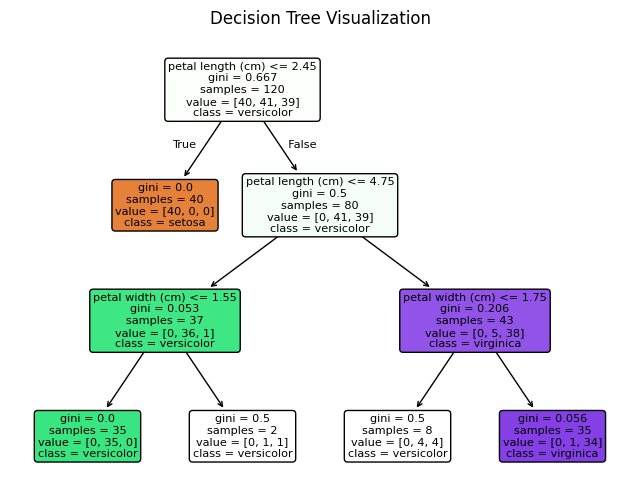

In [45]:
plt.figure(figsize=(8, 6))
plot_tree(tree, 
         feature_names=iris.feature_names,
         class_names=iris.target_names,
         filled=True,           # 색상 채우기
         rounded=True,          # 모서리 둥글게
)
plt.title('Decision Tree Visualization')
plt.show()

In [ ]:
#과제 1: 알고리즘 성능 비교
# Iris 데이터로 5가지 알고리즘 모두 실습
# 1번 같은 경우, LDA는 scaling을 해야해서 LDA만 빼고 해주세요. 속도는 정리 안하셔도 됩니다.

# 과제 2: Decision Tree 깊이 실험
# max_depth를 3~5까지 바꿔가며 성능 측정 → 그래프로 시각화

# 3.KNN 하이퍼파라미터 튜닝
# K값과 거리 측정 방법을 바꿔가며 실험 → 최적 조합 찾기

In [32]:
#  LDA 실습 

#데이터 로드
X, y = iris.data, iris.target

# LDA (3 클래스 → 2차원으로 축소)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

print(f"원본: {X.shape}")
print(f"LDA 후: {X_lda.shape}")

원본: (150, 4)
LDA 후: (150, 2)


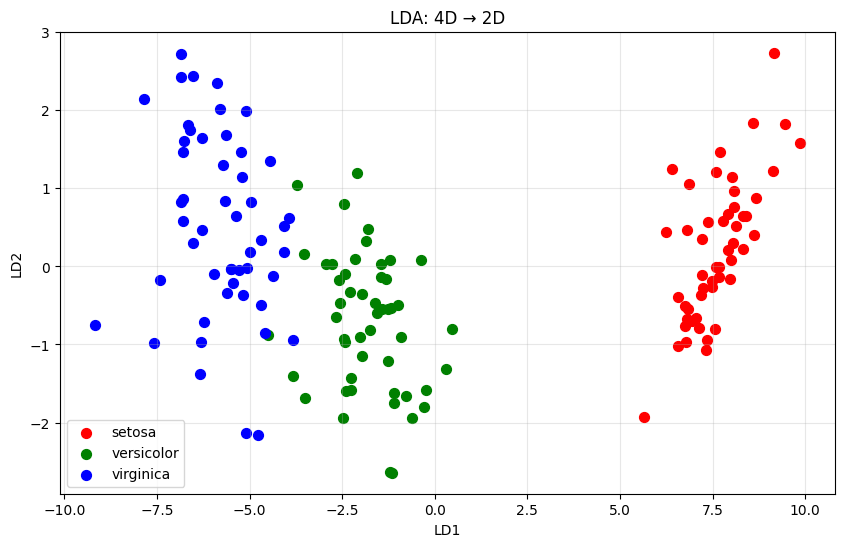

In [33]:
# 시각화
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X_lda[y==i, 0], X_lda[y==i, 1], 
               c=colors[i], label=iris.target_names[i], s=50)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA: 4D → 2D')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# KNN

In [42]:
scores = []
for i in range(1,30):
    knn = KNeighborsClassifier(i)
    score = cross_val_score(knn, X_train, y_train, scoring='accuracy').mean()
    scores.append(score)
scores # 3번의  score가 가장 높음

[np.float64(0.95),
 np.float64(0.95),
 np.float64(0.9583333333333334),
 np.float64(0.95),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9333333333333333),
 np.float64(0.9333333333333333),
 np.float64(0.9333333333333333),
 np.float64(0.95),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.95),
 np.float64(0.925),
 np.float64(0.9333333333333333),
 np.float64(0.9166666666666667),
 np.float64(0.9416666666666667),
 np.float64(0.9333333333333333),
 np.float64(0.9416666666666667),
 np.float64(0.9333333333333333),
 np.float64(0.9333333333333333)]

In [43]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
knn.score(X_test,y_test)

1.0

In [46]:
knn.predict(X_test)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [47]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
# KNN
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

In [ ]:
# KNN 모델 (K=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

In [ ]:
# 예측
y_pred = knn.predict(X_test)

In [ ]:
# 평가
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy:.3f}")

In [ ]:
# 각 샘플의 이웃 확인
distances, indices = knn.kneighbors(X_test[:1])
print(f"
첫 번째 샘플의 5개 이웃:")
print(f"거리: {distances[0]}")
print(f"인덱스: {indices[0]}")

In [ ]:
# 최적의 K 값 찾기
k_range = range(1, 31)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, 
                           cv=5, scoring='accuracy').mean()
    scores.append(score)

# 최적 K
best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k}")
print(f"Best Score: {max(scores):.3f}")

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, 'bo-')
plt.axvline(x=best_k, color='red', linestyle='--')
plt.xlabel('K')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN: Finding Optimal K')
plt.grid(True, alpha=0.3)
plt.show()